In [6]:
# --- Step 0: Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [7]:
# --- Step 1: Load raw data ---
df = pd.read_csv("../data/raw.csv")
print("Initial shape:", df.shape)
df.head()

Initial shape: (607, 12)


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [8]:
# --- Step 2: Overview ---
print(df.info())
print(df.describe())
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 73.8 KB
None
       Unnamed: 0    work_year        salary  salary_in_usd  remote_ratio
count  607.000000   607.000000  6.070000e+02     607.000000     607.00000
mean   303.000000  2021.405272  3.240001e+05  11

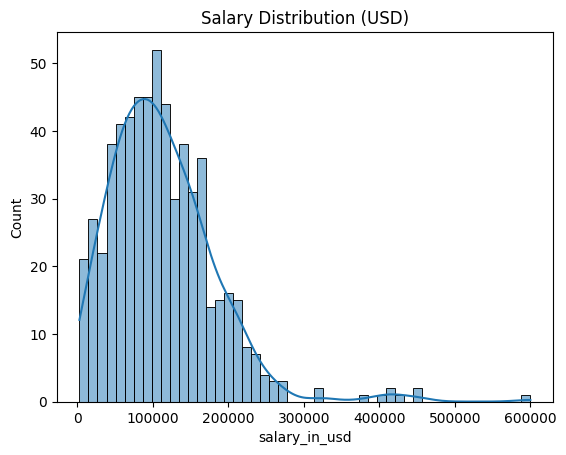

In [9]:
# --- Step 3: Target Distribution ---
sns.histplot(df['salary_in_usd'], kde=True, bins=50)
plt.title("Salary Distribution (USD)")
plt.show()


--- experience_level ---
experience_level
SE    280
MI    213
EN     88
EX     26
Name: count, dtype: int64


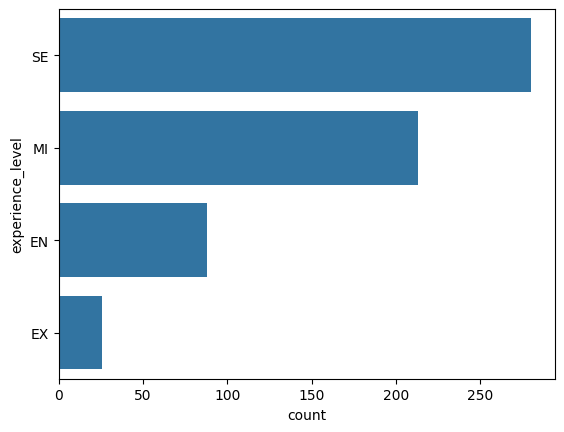


--- employment_type ---
employment_type
FT    588
PT     10
CT      5
FL      4
Name: count, dtype: int64


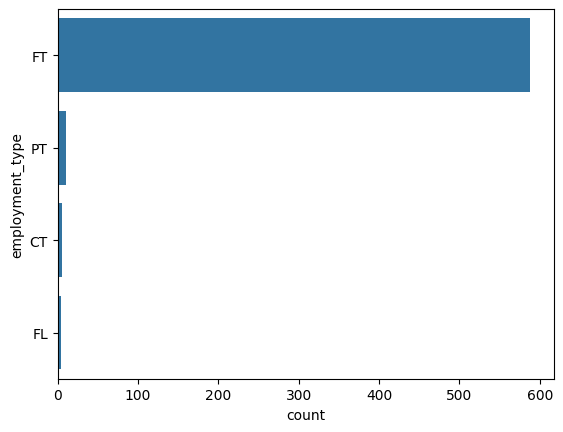


--- job_title ---
job_title
Data Scientist                143
Data Engineer                 132
Data Analyst                   97
Machine Learning Engineer      41
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer               8
Data Science Consultant         7
Name: count, dtype: int64


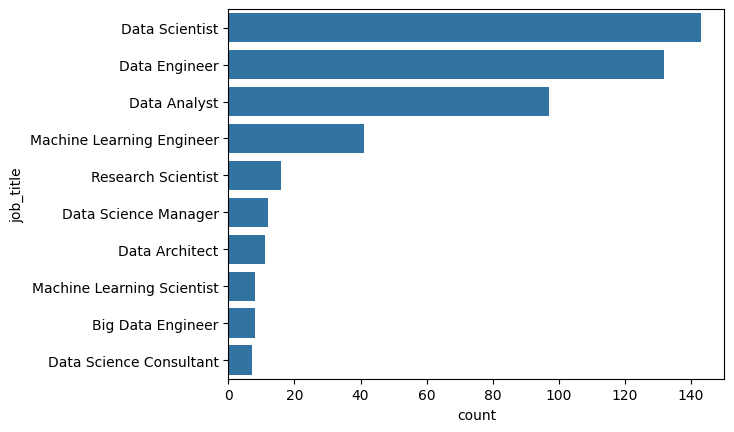


--- employee_residence ---
employee_residence
US    332
GB     44
IN     30
CA     29
DE     25
FR     18
ES     15
GR     13
JP      7
PK      6
Name: count, dtype: int64


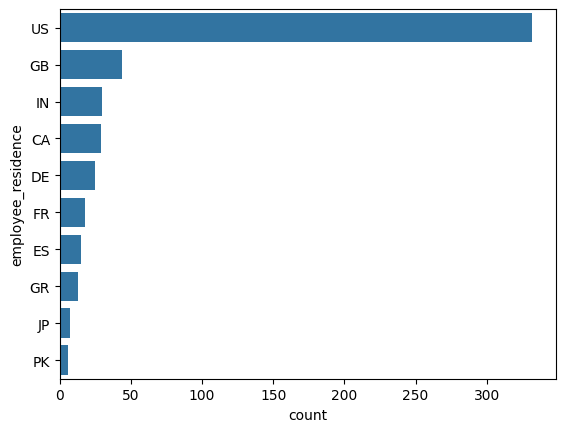


--- company_location ---
company_location
US    355
GB     47
CA     30
DE     28
IN     24
FR     15
ES     14
GR     11
JP      6
NL      4
Name: count, dtype: int64


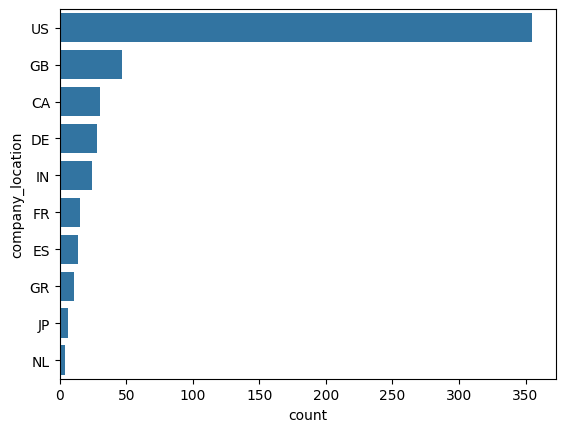


--- company_size ---
company_size
M    326
L    198
S     83
Name: count, dtype: int64


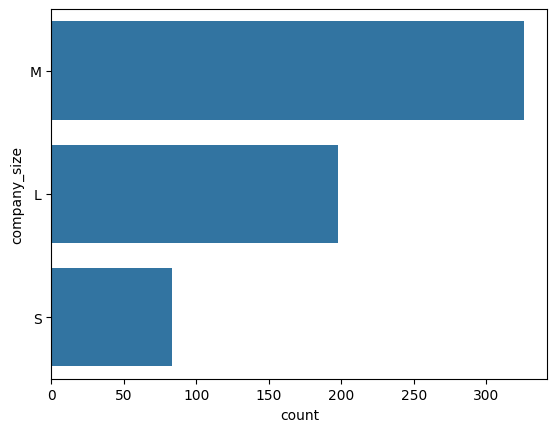

In [10]:
# --- Step 4: Categorical Exploration ---
categorical_cols = [
    'experience_level', 'employment_type', 'job_title',
    'employee_residence', 'company_location', 'company_size'
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))  # top 10 only
    sns.countplot(y=col, data=df, order=df[col].value_counts().index[:10])
    plt.show()

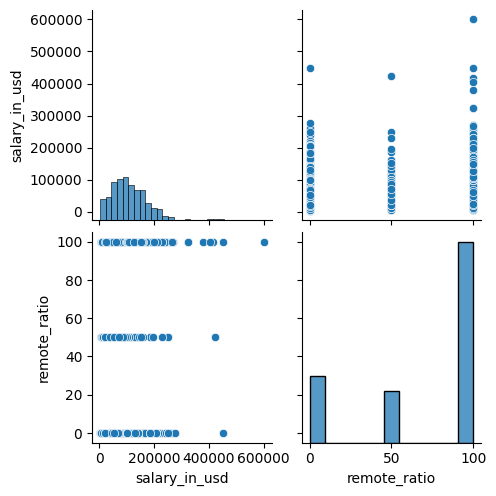

In [11]:
# --- Step 5: Numeric Correlations ---
numeric_cols = ['salary_in_usd', 'remote_ratio']
sns.pairplot(df[numeric_cols])
plt.show()

# --- Notes Section ---
# Add your observations here about skew, outliers, top job titles, missing data, etc.